# 2.795 arrecifes. ¿Sirve protegerlos?

¿Qué pasa si medimos las contribuciones de los peces en 2.795 arrecifes tropicales y comparamos los protegidos con los que no lo están? El resultado no es el que esperarías.

---

**Paper:** Marine protected areas marginally offset anthropogenic declines in tropical reef fish contributions to nature and people \
**Journal:** Nature Ecology & Evolution \
**DOI:** [10.1038/s41559-026-03008-2](https://doi.org/10.1038/s41559-026-03008-2)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-16-arrecifes-mpa-solo-5-porciento/notebook.ipynb)
· [▶️ Ver video](https://youtube.com/watch?v=pT8m2PGyfwI)

## El estudio más grande sobre MPAs tropicales

El equipo tomó datos de Reef Life Survey — buzos contando peces en 2.800 arrecifes — y midió 22 cosas que los peces hacen por el ecosistema: desde cuántos depredadores hay hasta cuánto nutriente reciclan. Con un modelo bayesiano, compararon cada arrecife contra un escenario contrafactual (¿cómo estaría ese arrecife si nunca hubiéramos llegado?).

El resultado del paper: las áreas marinas protegidas (MPAs) compensan *potencialmente* solo un 5% de la degradación causada por actividades humanas. Según el modelo, la biomasa de piscívoros (depredadores tope) cayó un 120% respecto al escenario sin humanos — 19 kg menos por hectárea de arrecife.

Aquí exploramos los datos observados directamente — sin el modelo contrafactual. Veamos qué dicen los números crudos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
CONTRIBUCION = 'biomasa_piscivoros'  # Cambia por: biomasa_herbivoros, riqueza_peces, etc.
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-03-16-arrecifes-mpa-solo-5-porciento'
FUENTE = 'Fuente: Flandrin et al. (2026), Nat Ecol Evol | DOI: 10.1038/s41559-026-03008-2'
COLOR_TOTAL = '#2563EB'      # Azul — protección total
COLOR_PARCIAL = '#D97706'    # Amber — protección parcial
COLOR_SIN = '#DC2626'        # Rojo — sin protección

# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os, urllib.request

style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/../../cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
prot = pd.read_csv('datos/contribuciones_por_proteccion.csv')
det = pd.read_csv('datos/contribuciones_por_proteccion_detallada.csv')
sites = pd.read_csv('datos/sitios_arrecifes.csv')
surveys = pd.read_csv('datos/surveys_contribuciones.csv')
edad = pd.read_csv('datos/efecto_edad_mpa.csv')

print(f"Sitios: {len(sites)} arrecifes tropicales")
print(f"Surveys: {len(surveys)} observaciones")
print(f"  Protección total: {(sites['proteccion']=='protección total').sum()}")
print(f"  Protección parcial: {(sites['proteccion']=='protección parcial').sum()}")
print(f"  Sin protección: {(sites['proteccion']=='sin protección').sum()}")

Sitios: 2795 arrecifes tropicales
Surveys: 6936 observaciones
  Protección total: 779
  Protección parcial: 650
  Sin protección: 1366


## 2.795 puntos en el mapa

Cada punto es un arrecife donde un equipo de buzos contó y pesó peces.

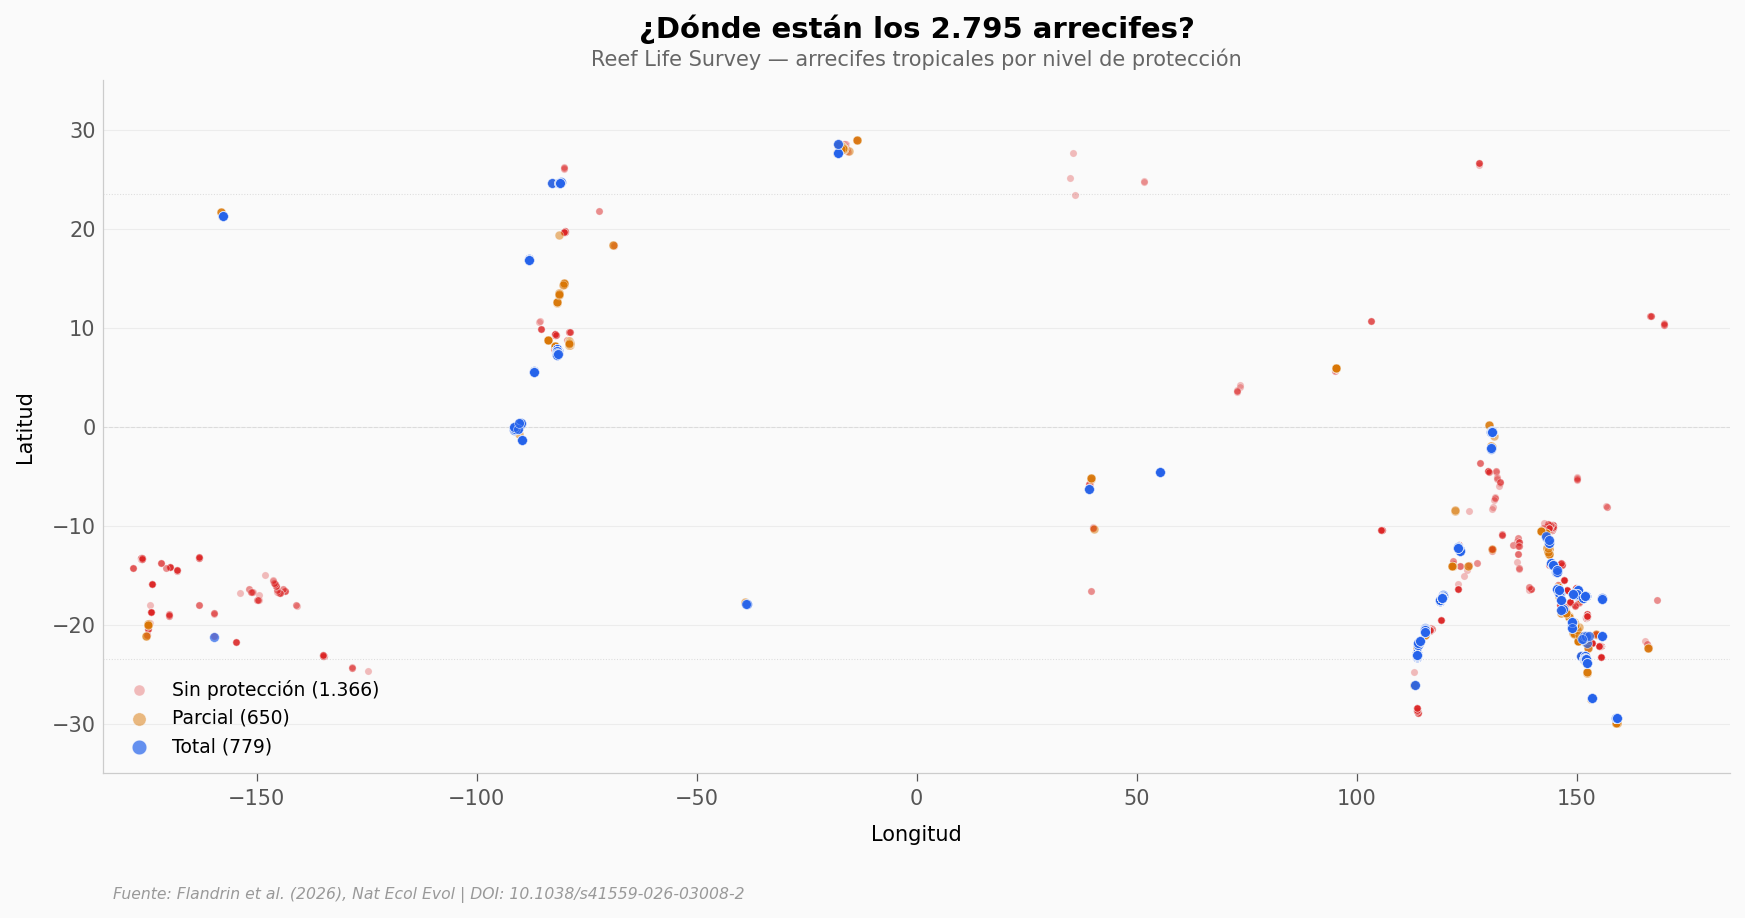

In [2]:
fig, ax = plt.subplots(figsize=(14, 6))

# Plot by protection status (sin protección primero para que quede atrás)
for prot_name, color, alpha, s, label in [
    ('sin protección', COLOR_SIN, 0.3, 12, 'Sin protección (1.366)'),
    ('protección parcial', COLOR_PARCIAL, 0.5, 18, 'Parcial (650)'),
    ('protección total', COLOR_TOTAL, 0.7, 22, 'Total (779)'),
]:
    sub = sites[sites['proteccion'] == prot_name]
    ax.scatter(sub['lon'], sub['lat'], color=color, s=s, alpha=alpha,
               edgecolors='white', linewidths=0.3, label=label, zorder=3 if 'total' in prot_name else 2)

# Trópicos
ax.axhline(y=23.5, color='#999999', linewidth=0.5, linestyle=':', alpha=0.3)
ax.axhline(y=-23.5, color='#999999', linewidth=0.5, linestyle=':', alpha=0.3)
ax.axhline(y=0, color='#999999', linewidth=0.5, linestyle='--', alpha=0.2)

ax.legend(fontsize=9, loc='lower left', framealpha=0.9, markerscale=1.5)
ax.set_title('¿Dónde están los 2.795 arrecifes?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Reef Life Survey — arrecifes tropicales por nivel de protección',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Longitud', fontsize=10)
ax.set_ylabel('Latitud', fontsize=10)
ax.set_xlim(-185, 185)
ax.set_ylim(-35, 35)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mapa_arrecifes.png', dpi=200, bbox_inches='tight')
plt.show()

Caribe, Indo-Pacífico, Triángulo de Coral, Gran Barrera, Pacífico oriental — todo el cinturón tropical. De los 2.795 sitios, 779 tienen protección total, 650 parcial y 1.366 no están protegidos.

¿Hay diferencia entre los azules y los rojos? Veamos las contribuciones de los peces.

## ¿Más protección = más peces?

Comparamos la biomasa de piscívoros (depredadores), herbívoros y la riqueza de especies. Los valores están estandarizados: cero es el promedio global, positivo está por encima, negativo por debajo.

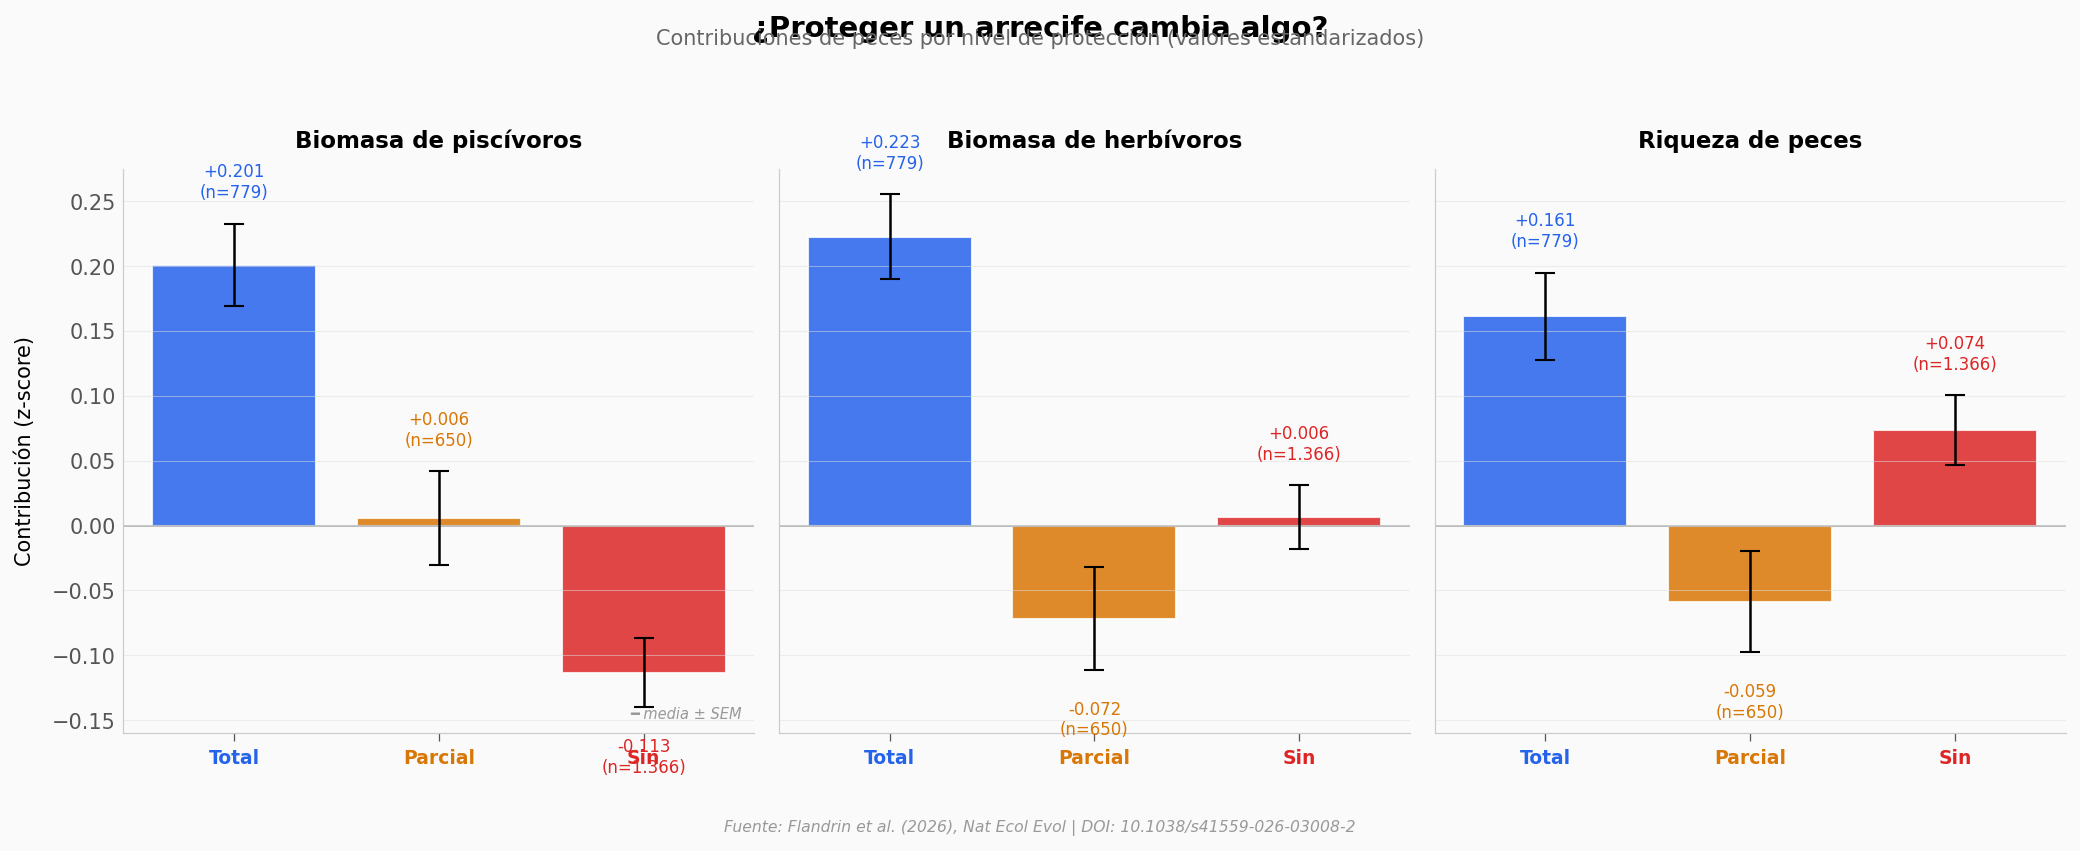

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

contribs = [
    ('biomasa_piscivoros', 'Biomasa de piscívoros'),
    ('biomasa_herbivoros', 'Biomasa de herbívoros'),
    ('riqueza_peces', 'Riqueza de peces'),
]
colors = [COLOR_TOTAL, COLOR_PARCIAL, COLOR_SIN]
labels_prot = ['Total', 'Parcial', 'Sin']
order = ['protección total', 'protección parcial', 'sin protección']

for ax_i, (col_base, title) in zip(axes, contribs):
    means = []
    stds = []
    ns = []
    for p in order:
        row = prot[prot['proteccion'] == p]
        means.append(row[f'{col_base}_mean'].values[0])
        stds.append(row[f'{col_base}_std'].values[0])
        ns.append(int(row[f'{col_base}_count'].values[0]))
    
    sems = [s / np.sqrt(n) for s, n in zip(stds, ns)]
    bars = ax_i.bar(range(3), means, color=colors, alpha=0.85, edgecolor='white',
                    linewidth=1, yerr=sems, capsize=5, error_kw={'linewidth': 1.2})
    
    # Inline labels
    for i, (m, n) in enumerate(zip(means, ns)):
        y_pos = m + sems[i] + 0.02 if m >= 0 else m - sems[i] - 0.05
        ax_i.text(i, y_pos, f'{m:+.3f}\n(n={n:,}'.replace(',', '.') + ')', 
                  ha='center', fontsize=8, color=colors[i])
    
    ax_i.axhline(y=0, color='#333333', linewidth=0.8, linestyle='-', alpha=0.3)
    ax_i.set_xticks(range(3))
    ax_i.set_xticklabels(labels_prot, fontsize=9, fontweight='bold')
    for tick, color in zip(ax_i.get_xticklabels(), colors):
        tick.set_color(color)
    ax_i.set_title(title, fontsize=11, fontweight='bold', pad=10)

axes[0].set_ylabel('Contribución (z-score)', fontsize=10)
axes[0].text(0.98, 0.02, '━ media ± SEM', transform=axes[0].transAxes,
             fontsize=7, color='#999999', ha='right', va='bottom', style='italic')

fig.suptitle('¿Proteger un arrecife cambia algo?', fontsize=14, fontweight='bold', y=1.05)
fig.text(0.5, 1.01, 'Contribuciones de peces por nivel de protección (valores estandarizados)',
         fontsize=10, color='#666666', ha='center')

plt.tight_layout()
fig.text(0.5, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic', ha='center')
plt.savefig('figuras/contribuciones_proteccion.png', dpi=200, bbox_inches='tight')
plt.show()

Hay diferencia — pero no la que esperarías. Los arrecifes con protección total tienen +0,201 desviaciones estándar más de biomasa de piscívoros que los sin protección. Eso da un Cohen's d de 0,33 — un efecto pequeño-a-mediano (Mann-Whitney p < 0,001 porque n es enorme, pero el tamaño del efecto es modesto).

La protección parcial apenas se distingue de no tener protección (piscívoros: +0,006 vs -0,113; Cohen's d = 0,12, n = 650 vs 1.366). Los herbívoros y la riqueza de especies muestran un patrón aún más plano.

## ¿Importa cuánto tiempo lleva protegido?

El paper argumenta que solo las MPAs antiguas y con protección total muestran beneficios marcados. ¿Se ve en los datos?

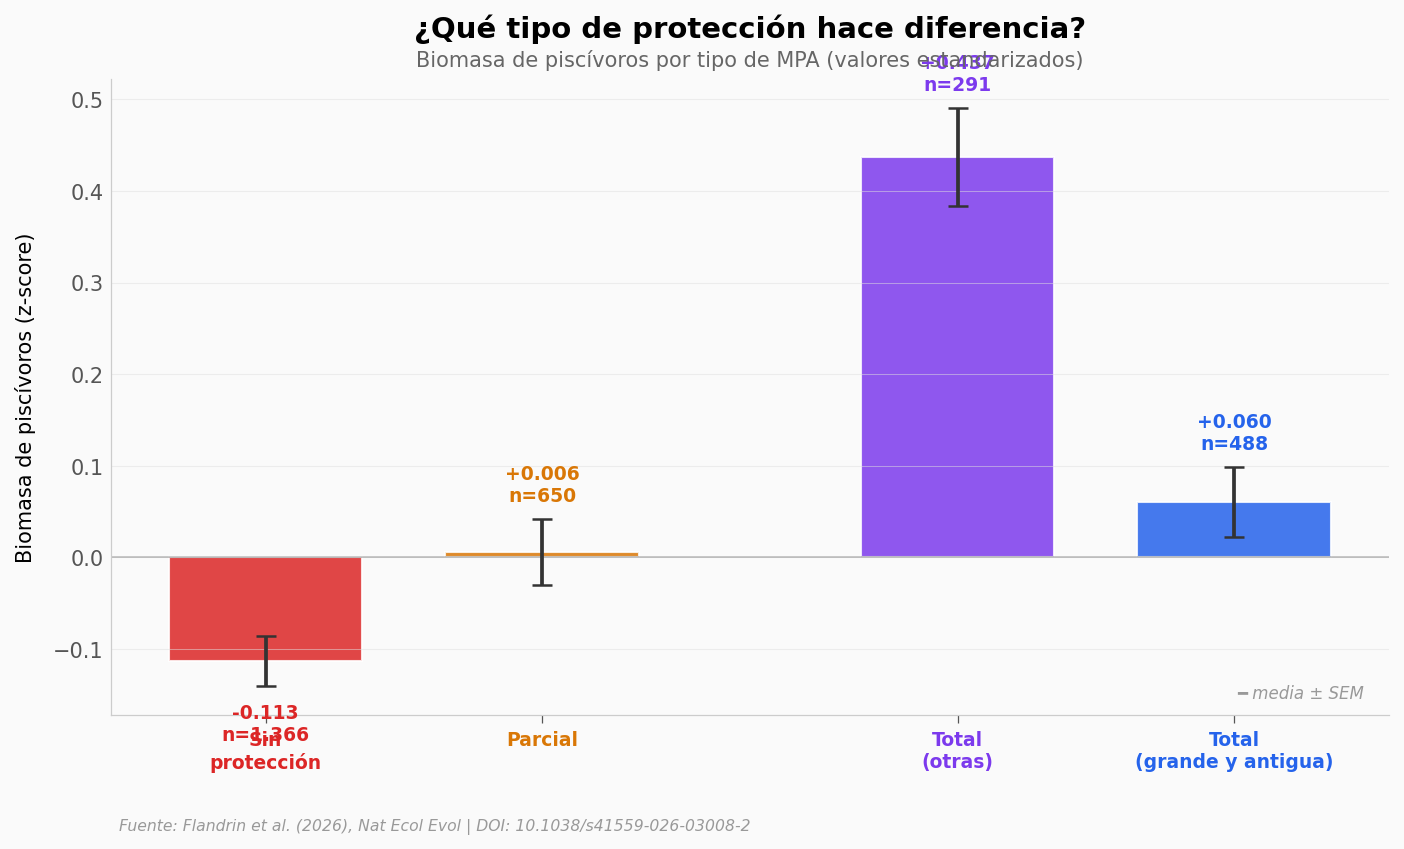

In [4]:
fig, ax = plt.subplots(figsize=(11, 5.5))

# Detailed protection
det_order = ['sin protección', 'parcial', 'total (otras)', 'total (grande y antigua)']
det_colors = [COLOR_SIN, COLOR_PARCIAL, '#7C3AED', COLOR_TOTAL]
det_labels = ['Sin\nprotección', 'Parcial', 'Total\n(otras)', 'Total\n(grande y antigua)']

means_d = []
stds_d = []
ns_d = []
for p in det_order:
    row = det[det['proteccion_detallada'] == p]
    means_d.append(row['biomasa_piscivoros_mean'].values[0])
    stds_d.append(row['biomasa_piscivoros_std'].values[0])
    ns_d.append(int(row['biomasa_piscivoros_count'].values[0]))

sems_d = [s / np.sqrt(n) for s, n in zip(stds_d, ns_d)]
positions = [0, 1, 2.5, 3.5]

for i, (pos, m, sem, n, color) in enumerate(zip(positions, means_d, sems_d, ns_d, det_colors)):
    ax.bar(pos, m, width=0.7, color=color, alpha=0.85, edgecolor='white', linewidth=1)
    ax.errorbar(pos, m, yerr=sem, fmt='none', color='#333333', capsize=5, capthick=1.2)
    y_pos = m + sem + 0.02 if m >= 0 else m - sem - 0.06
    ax.text(pos, y_pos, f'{m:+.3f}\nn={n:,}'.replace(',', '.'), 
            ha='center', fontsize=9, color=color, fontweight='bold')

ax.axhline(y=0, color='#333333', linewidth=0.8, linestyle='-', alpha=0.3)
ax.set_xticks(positions)
ax.set_xticklabels(det_labels, fontsize=9, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), det_colors):
    tick.set_color(color)

ax.set_title('¿Qué tipo de protección hace diferencia?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Biomasa de piscívoros por tipo de MPA (valores estandarizados)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('Biomasa de piscívoros (z-score)', fontsize=10)
ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/proteccion_detallada.png', dpi=200, bbox_inches='tight')
plt.show()

Sorpresa: las "otras" MPAs con protección total (+0,437) superan a las grandes y antiguas (+0,060) — Cohen's d = 0,43 (mediano), Mann-Whitney p < 0,001, n = 291 vs 488. Esto sugiere un sesgo de selección — las MPAs "otras" podrían haberse establecido en arrecifes que ya estaban en buen estado. El modelo bayesiano del paper corrige este sesgo comparando cada arrecife contra su escenario contrafactual.

La protección parcial (+0,006) no se distingue de la ausencia de protección. Eso es consistente con el hallazgo del paper: solo las MPAs con protección total y bien implementadas muestran beneficios.

## ¿Cómo se distribuyen los piscívoros?

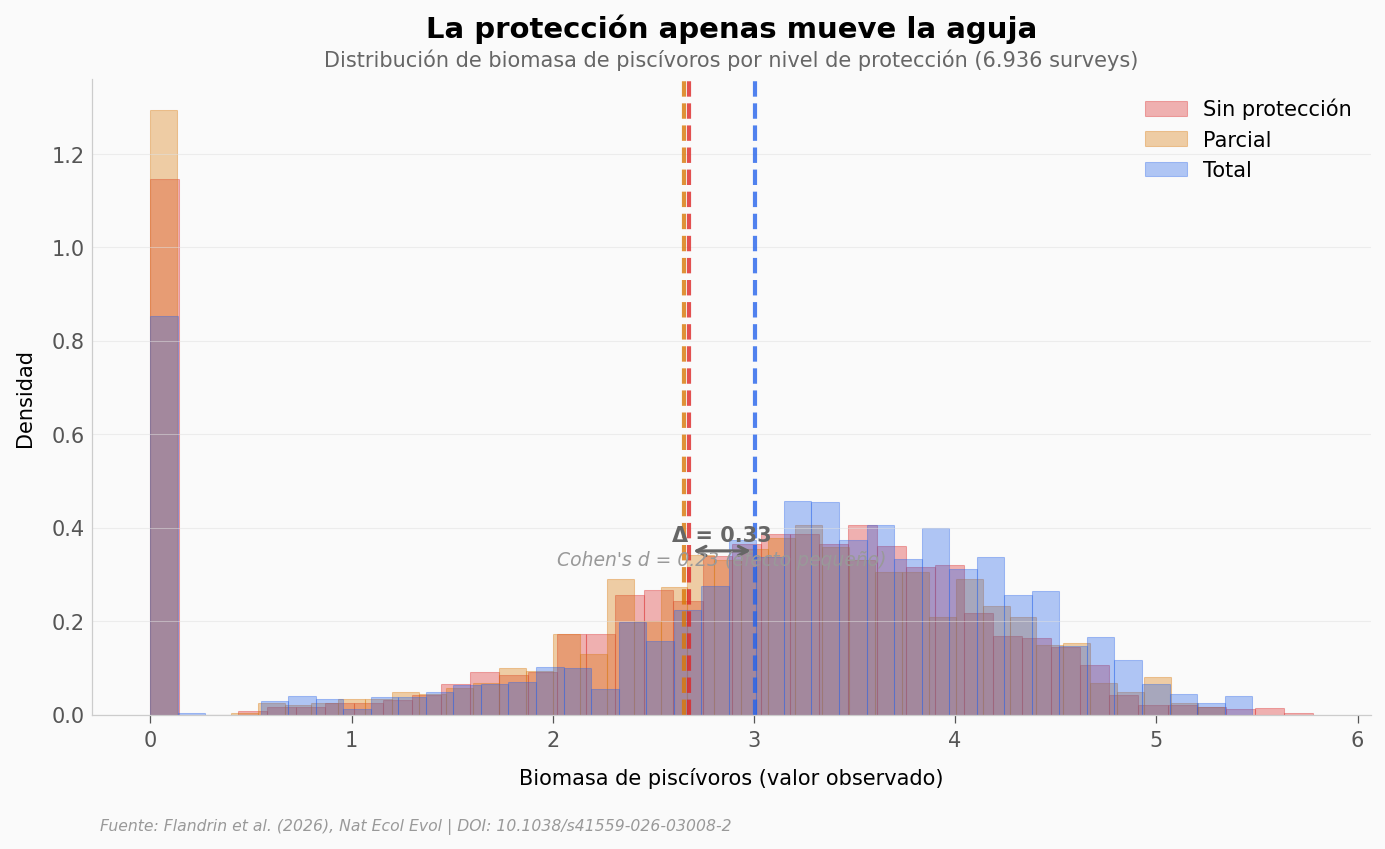

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))

for prot_name, color, label in [
    ('sin protección', COLOR_SIN, 'Sin protección'),
    ('protección parcial', COLOR_PARCIAL, 'Parcial'),
    ('protección total', COLOR_TOTAL, 'Total'),
]:
    sub = surveys[surveys['proteccion'] == prot_name]['biomasa_piscivoros'].dropna()
    ax.hist(sub, bins=40, alpha=0.35, color=color, edgecolor=color, linewidth=0.5, label=label, density=True)
    # Vertical line for mean
    ax.axvline(x=sub.mean(), color=color, linewidth=2, linestyle='--', alpha=0.8)

# Annotate means
full = surveys[surveys['proteccion']=='protección total']['biomasa_piscivoros'].dropna()
out = surveys[surveys['proteccion']=='sin protección']['biomasa_piscivoros'].dropna()
ax.annotate('', xy=(full.mean(), 0.35), xytext=(out.mean(), 0.35),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
diff = full.mean() - out.mean()
mid = (full.mean() + out.mean()) / 2
ax.text(mid, 0.37, f'Δ = {diff:.2f}', ha='center', fontsize=10, fontweight='bold', color='#666666')

# Cohen's d
pooled_std = np.sqrt(((len(full)-1)*full.std()**2 + (len(out)-1)*out.std()**2) / (len(full)+len(out)-2))
d = abs(diff) / pooled_std
ax.text(mid, 0.32, f"Cohen's d = {d:.2f} (efecto pequeño)", ha='center', fontsize=9, color='#999999', style='italic')

ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
ax.set_title('La protección apenas mueve la aguja',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Distribución de biomasa de piscívoros por nivel de protección (6.936 surveys)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Biomasa de piscívoros (valor observado)', fontsize=10)
ax.set_ylabel('Densidad', fontsize=10)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_piscivoros.png', dpi=200, bbox_inches='tight')
plt.show()

Las tres distribuciones se superponen casi por completo. A nivel de sitio (datos estandarizados), la diferencia es de 0,31 desviaciones estándar entre protección total y sin protección, con un Cohen's d de 0,33 (efecto pequeño-a-mediano, Mann-Whitney p < 0,001, n = 779 vs 1.366). A nivel de survey (histograma, valores crudos), el Cohen's d baja a 0,23 (efecto pequeño, n = 1.995 vs 2.443) — en ambos casos, un efecto modesto.

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|--------|
| 2.795 arrecifes tropicales analizados | ✅ | 2.795 sitios con coordenadas en la franja tropical |
| Protección total muestra mayor biomasa de piscívoros | ✅ | +0,201 vs -0,113 (z-score), Mann-Whitney p < 0,001, Cohen's d = 0,33 (pequeño-a-mediano, n = 779 vs 1.366) |
| Protección parcial ≈ sin protección | ✅ | Piscívoros: +0,006 vs -0,113 — Cohen's d = 0,12 (negligible, n = 650 vs 1.366) |
| Solo MPAs antiguas y con protección total muestran beneficios marcados | ⚠️ | Los datos muestran que "total (otras)" > "total (antigua/grande)", lo que sugiere sesgo de selección. El paper usa un modelo contrafactual para corregir esto |
| MPAs compensan solo ~5% de la degradación | ⚠️ | Este dato viene del modelo bayesiano contrafactual, no de la comparación simple que hacemos aquí. El paper lo enmarca como estimación (*potentially*), no como certeza |

> **Limitaciones:** (1) Los datos son contribuciones estandarizadas (z-scores), no biomasa en kg/ha. Los valores headline del paper (120% decline, 19 kg/ha, 5%) vienen del modelo bayesiano que no replicamos. (2) Diseño observacional — las diferencias no prueban que la protección *cause* mayor biomasa (sesgo de selección: se protegen arrecifes ya buenos). (3) El modelo del paper corrige estos sesgos con escenarios contrafactuales.

---

## Ahora tú

1. **¿Cambia con herbívoros?** Cambia `CONTRIBUCION = 'biomasa_herbivoros'` en la configuración y re-ejecuta. ¿El patrón es el mismo?

2. **¿Hay un umbral de edad?** Filtra los sitios protegidos y grafica biomasa de piscívoros vs edad de la MPA. ¿A partir de cuántos años se nota la diferencia?

3. **¿Importa la ubicación?** Compara las contribuciones entre el Caribe (lon < -60) y el Indo-Pacífico (lon > 60). ¿El efecto de protección es igual en ambas regiones?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Comparar contribuciones por región: Caribe vs Indo-Pacífico

caribe = sites[sites['lon'] < -60]
indopacifico = sites[sites['lon'] > 60]

for region, nombre in [(caribe, 'Caribe'), (indopacifico, 'Indo-Pacífico')]:
    print(f"\n{nombre} ({len(region)} sitios):")
    for prot_name in ['protección total', 'protección parcial', 'sin protección']:
        sub = region[region['proteccion'] == prot_name]
        if len(sub) > 0:
            print(f"  {prot_name} (n={len(sub)}): piscívoros = {sub['biomasa_piscivoros'].mean():+.3f}")
        else:
            print(f"  {prot_name}: sin datos")


Caribe (633 sitios):
  protección total (n=181): piscívoros = +0.383
  protección parcial (n=137): piscívoros = +0.052
  sin protección (n=315): piscívoros = -0.308

Indo-Pacífico (2005 sitios):
  protección total (n=581): piscívoros = +0.140
  protección parcial (n=471): piscívoros = +0.030
  sin protección (n=953): piscívoros = +0.011


---

## Créditos

- **Paper:** Flandrin, U. et al. (2026). Marine protected areas marginally offset anthropogenic declines in tropical reef fish contributions to nature and people. *Nature Ecology & Evolution*. DOI: [10.1038/s41559-026-03008-2](https://doi.org/10.1038/s41559-026-03008-2)
- **Datos:** [Zenodo](https://doi.org/10.5281/zenodo.17602130) — Reef Life Survey data, procesados con modelos bayesianos
- **Notebook:** [Ciencia a Mordiscos — El Lab](https://cienciaamordiscos.com)
- **Licencia notebook:** [CC-BY 4.0](https://creativecommons.org/licenses/by/4.0/)